# 摩擦音モデル — Phase 3: 波動管モデルへの統合（ハイブリッドモデル）

## 初期実装の問題点と修正方針

### 問題：摩擦音が区別できない

初期の「波動管へのノイズ直接注入」では /s/ /ɕ/ /f/ がほぼ同じノイズに聞こえた。  
原因は 2 つある。

**① 壁面損失係数が大きすぎる（`ALPHA_WALL = 0.30`）**

/s/ の前方腔（約 7 セクション、断面積 ≈ 2 cm²）を進む波のセクション損失：

$$L = e^{-0.30/\sqrt{2.0}} \approx 0.81 \quad \text{per section}$$

7 セクション往復後のエネルギー：$0.81^{14} \approx 0.046$（96% 消失）→ **Q ≈ 2 の過減衰**

**② 前方腔が短い（7 セクション ≈ 2.7 cm）**

44 セクションで 17 cm を分割するため、/s/ の前方腔は 7 セクションしかなく、  
損失を下げても Phase 1・2 の明示的バンドパスフィルタほどの鋭い共鳴は難しい。

### 修正方針：ハイブリッドモデル

```
摩擦ノイズ：white noise → 前後腔フィルタ（Phase 2 の明示フィルタ）→ ┐
                                                                      ├─ 加算 → 出力
有声成分  ：LF パルス   → 波動管（全 44 セクション, α=0.04）        → ┘
```

- **ノイズ**：Phase 2 で有効性が確認済みの前後腔フィルタ → /s/ /ɕ/ /f/ の違いが明確
- **声帯音源**：波動管が全声道フォルマントを正確に反映
- **CV 遷移**：フレームごとに形状・Re を更新し、ノイズが自然に消える動作を維持

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#1e293b', 'axes.facecolor': '#0f172a',
    'axes.edgecolor': '#475569',   'axes.labelcolor': '#cbd5e1',
    'xtick.color': '#94a3b8',      'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0',       'grid.color': '#334155',
    'grid.linestyle': '--',        'grid.alpha': 0.6,
    'lines.linewidth': 1.6,
})

FS        = 44100
C         = 343.0
NU        = 1.5e-5
RE_CRIT   = 1800.0
N_SEC     = 44
OVERSAMPLE = 2

def reynolds_number(Q, Ac):
    return (Q / Ac) * (2 * np.sqrt(Ac / np.pi)) / NU

def noise_amplitude(Re, alpha=1.0):
    return float(np.maximum(0.0, Re - RE_CRIT) ** alpha)

print('準備完了')

準備完了


---
## 1. 診断：ALPHA_WALL が共鳴に与える影響

/s/ 形状の波動管にインパルスを注入し、ALPHA_WALL ごとの周波数特性を比較する。

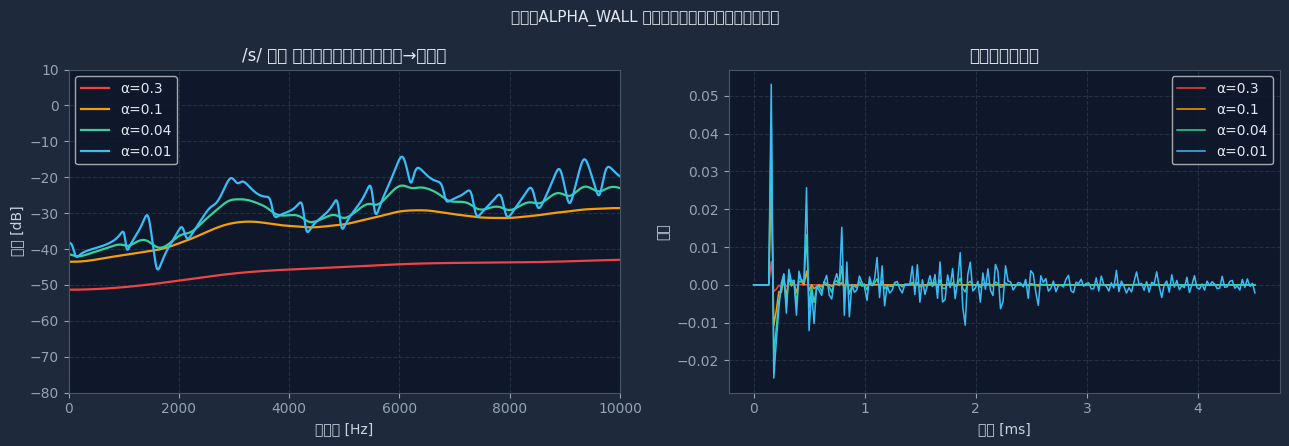

/s/ 収縮セクション = 37  前方腔 = 6 セクション
α=0.30（旧設定）ではQ≈2。α=0.04以下で共鳴ピークが現れ始める。


In [2]:
class WaveguideVocalTract:
    """Kelly–Lochbaum デジタル波動管（Python オフライン版）。"""
    LIP_REFL  = -0.85
    GLOT_REFL =  0.75

    def __init__(self, areas, fs=FS, oversample=OVERSAMPLE, alpha_wall=0.04):
        self.N          = len(areas)
        self.fs         = fs
        self.oversample = oversample
        self.alpha_wall = alpha_wall
        self.set_areas(areas)
        self.reset()

    def set_areas(self, areas):
        self.areas = np.clip(areas, 0.05, None)
        self.k    = (self.areas[:-1] - self.areas[1:]) / (self.areas[:-1] + self.areas[1:])
        self.loss = np.exp(-self.alpha_wall / np.sqrt(self.areas))

    def reset(self):
        self.right = np.zeros(self.N)
        self.left  = np.zeros(self.N)

    def step(self, glottal=0.0, noise=0.0, noise_sec=-1):
        N  = self.N; k = self.k; lo = self.loss
        r  = self.right; l = self.left
        new_r = np.empty(N); new_l = np.empty(N)
        new_r[0] = glottal + self.GLOT_REFL * l[0]
        for i in range(N - 1):
            new_r[i+1] = ((1.0 + k[i]) * r[i]   - k[i] * l[i+1]) * lo[i]
            new_l[i]   = ((1.0 - k[i]) * l[i+1] + k[i] * r[i])   * lo[i]
        new_l[N-1] = self.LIP_REFL * r[N-1] * lo[N-1]
        if noise_sec >= 0 and noise != 0.0:
            new_r[noise_sec] += noise * 0.5
            new_l[noise_sec] += noise * 0.5
        self.right = new_r; self.left = new_l
        return float(r[N-1])

    def impulse_response(self, n_samples=4096, inject_sec=None):
        self.reset()
        ir = np.zeros(n_samples)
        for n in range(n_samples):
            imp = 1.0 if n == 0 else 0.0
            if inject_sec is None:
                ir[n] = self.step(glottal=imp)
            else:
                ir[n] = self.step(noise=imp, noise_sec=inject_sec)
        return ir

    def synthesize(self, glottal_seq, noise_seq=None, noise_sec=-1):
        N_out = len(glottal_seq); output = np.zeros(N_out)
        for n in range(N_out):
            g  = float(glottal_seq[n]) * 0.5
            ns = (float(noise_seq[n]) * 0.5) if noise_seq is not None else 0.0
            for _ in range(self.oversample):
                out = self.step(g, ns, noise_sec)
            output[n] = out
        return output


# ── 声道形状の定義 ───────────────────────────────────────────────
def interp_areas(cp, n=N_SEC):
    return np.interp(np.linspace(0,1,n), np.linspace(0,1,len(cp)), cp)

VOWEL_CP = {
    'a': [1.13,1.13,5.31,2.01,1.13,1.54,3.14,5.31,7.07,9.08,11.34,11.34,9.08,7.07,6.16,8.04],
    'i': [1.13,1.13,8.04,8.04,8.04,8.04,8.04,8.04,4.52,2.01, 0.79, 0.79,0.79,1.13,1.54,4.52],
    'u': [1.13,1.13,7.07,7.07,7.07,7.07,5.31,2.55,1.54,3.80, 5.31, 4.52,3.80,3.14,1.54,2.01],
    'e': [1.13,1.13,7.07,7.07,7.07,7.07,6.16,4.52,2.55,2.01, 2.01, 2.55,3.14,3.80,3.80,4.52],
    'o': [1.13,1.13,7.07,3.80,2.01,1.54,2.01,3.80,6.16,9.08,11.34,11.34,8.04,5.31,3.80,1.54],
}
VOWEL_AREAS = {v: interp_areas(np.array(cp)) for v, cp in VOWEL_CP.items()}

def make_fric_shape(base, sec, w=2, Ac=0.12):
    a = base.copy()
    for di in range(-w, w+1):
        idx = sec + di
        if 0 <= idx < len(a):
            wt     = 0.5 * (1 + np.cos(np.pi * abs(di) / (w+1)))
            a[idx] = max(Ac, Ac + (base[idx] - Ac) * (1 - wt))
    return a

FRIC_SHAPES = {
    '/s/': make_fric_shape(VOWEL_AREAS['i'], 37, Ac=0.12),
    '/ɕ/': make_fric_shape(VOWEL_AREAS['i'], 32, Ac=0.15),
    '/f/': make_fric_shape(VOWEL_AREAS['u'], 41, Ac=0.20),
}

# ── ALPHA_WALL 別の周波数特性比較 ────────────────────────────────
s_areas = FRIC_SHAPES['/s/']
i_c     = int(np.argmin(s_areas))
alphas  = [0.30, 0.10, 0.04, 0.01]
colors  = ['#ef4444', '#f59e0b', '#34d399', '#38bdf8']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for alpha, col in zip(alphas, colors):
    wg = WaveguideVocalTract(s_areas, alpha_wall=alpha)
    ir = wg.impulse_response(8192, inject_sec=i_c)
    f, H = signal.freqz(ir, worN=4096, fs=FS)
    axes[0].plot(f, 20*np.log10(np.abs(H)+1e-10), color=col, label=f'α={alpha}')
    axes[1].plot(np.arange(200)/FS*1000, ir[:200], color=col, label=f'α={alpha}', linewidth=1.1)

axes[0].set(xlabel='周波数 [Hz]', ylabel='振幅 [dB]',
            title='/s/ 形状 周波数特性（収縮部注入→口唇）',
            xlim=(0,10000), ylim=(-80,10))
axes[0].legend(); axes[0].grid(True)
axes[1].set(xlabel='時間 [ms]', ylabel='振幅',
            title='インパルス応答')
axes[1].legend(); axes[1].grid(True)
plt.suptitle('診断：ALPHA_WALL が大きいほど共鳴ピークが潰れる', fontsize=11)
plt.tight_layout()
plt.show()
print(f'/s/ 収縮セクション = {i_c}  前方腔 = {(N_SEC-1-i_c)} セクション')
print('α=0.30（旧設定）ではQ≈2。α=0.04以下で共鳴ピークが現れ始める。')

---
## 2. ハイブリッドモデルの実装

### Phase 2 のフィルタ関数（再定義）

In [3]:
def resonator_sos(f, bw, fs=FS):
    r = np.exp(-np.pi * bw / fs)
    poles = [r*np.exp(1j*2*np.pi*f/fs), r*np.exp(-1j*2*np.pi*f/fs)]
    return signal.zpk2sos([], poles, 1.0)

def front_cavity_filter(L_m, fs=FS):
    nyq   = fs / 2.0
    f1    = C / (4 * L_m)
    hp    = signal.butter(3, max(200.,f1/3.)/nyq, btype='high', output='sos')
    lo, hi = max(300.,f1*0.60), min(nyq-200., f1*1.40)
    bp    = signal.butter(2, [lo/nyq, hi/nyq], btype='band', output='sos')
    return hp, bp, f1

def back_cavity_filter(L_m, fs=FS, n=3):
    nyq = fs / 2.0
    res = []
    for k in range(1, n+1):
        fn = (2*k-1)*C/(4*L_m)
        if fn >= nyq: break
        res.append((fn, fn*0.12, resonator_sos(fn, fn*0.12, fs)))
    return res

def constriction_info(areas, Q_ccps=200.0):
    i_c = int(np.argmin(areas))
    Ac  = float(areas[i_c]) * 1e-4
    Q   = Q_ccps * 1e-6
    Re  = reynolds_number(Q, Ac)
    sec_len = 0.17 / (N_SEC - 1)
    return {
        'section':   i_c,
        'Ac_cm2':    float(areas[i_c]),
        'Re':        Re,
        'sigma':     noise_amplitude(Re),
        'turbulent': Re > RE_CRIT,
        'L_front_m': (N_SEC-1-i_c) * sec_len,
        'L_back_m':  i_c            * sec_len,
    }

# 声門音源
def glottal_pulse(T0):
    Tp = int(0.40*T0); Tn = int(0.30*T0)
    p  = np.zeros(T0)
    p[:Tp]      = np.linspace(0,1,Tp)**2
    p[Tp:Tp+Tn] = np.linspace(1,0,Tn)
    return p

def make_glottal(n, f0=120., fs=FS, amp=1.0, jitter=0.004):
    T0  = int(fs/f0)
    out = np.zeros(n)
    pos = 0
    rng = np.random.default_rng(42)
    while pos < n:
        Tc  = int(T0*(1+rng.uniform(-jitter,jitter)))
        Tc  = max(int(fs/400), min(int(fs/50), Tc))
        pu  = glottal_pulse(Tc)
        end = min(pos+Tc, n)
        out[pos:end] += pu[:end-pos]
        pos += Tc
    out = np.diff(out, prepend=out[0])
    pk  = np.max(np.abs(out))
    if pk > 1e-10: out = out/pk * amp
    return out.astype(np.float32)

print('フィルタ・音源関数 定義完了')

フィルタ・音源関数 定義完了


In [4]:
def synth_fric(areas, voiced=False, f0=130., Q_ccps=200.,
               gain=0.60, vr=0.25, duration=1.5, fs=FS, seed=42):
    """
    ハイブリッド摩擦音合成。
    noise  : white → front_cavity_filter → back_cavity_filter
    voiced : LF pulse → WaveguideVocalTract (alpha_wall=0.04)
    """
    rng  = np.random.default_rng(seed)
    N    = int(duration * fs)
    info = constriction_info(areas, Q_ccps)
    REF  = 5000.0

    # ノイズ成分
    noise = rng.standard_normal(N).astype(np.float64)
    hp, bp, f1 = front_cavity_filter(info['L_front_m'], fs)
    noise = signal.sosfilt(hp, noise)
    noise = signal.sosfilt(bp, noise)
    for _,_,sos in back_cavity_filter(info['L_back_m'], fs):
        noise = signal.sosfilt(sos, noise)
    n_gain = gain * (1-vr) * min(1.0, info['sigma']/REF)
    pk = np.max(np.abs(noise))
    if pk > 1e-10: noise = noise/pk * n_gain

    # 有声成分
    if voiced:
        glot = make_glottal(N, f0=f0, fs=fs, amp=gain*vr)
        wg   = WaveguideVocalTract(areas, fs=fs, alpha_wall=0.04)
        vo   = wg.synthesize(glot)
        pk_v = np.max(np.abs(vo))
        if pk_v > 1e-10: vo = vo/pk_v * gain*vr
    else:
        vo = np.zeros(N)

    fade = int(0.02*fs)
    env  = np.ones(N)
    env[:fade]  = np.linspace(0,1,fade)
    env[-fade:] = np.linspace(1,0,fade)
    wav = ((noise + vo) * env).astype(np.float32)
    return np.clip(wav, -0.95, 0.95), info

print('synth_fric() 定義完了')

synth_fric() 定義完了


---
## 3. 無声摩擦音の合成と試聴

In [5]:
for label, areas in FRIC_SHAPES.items():
    wav, info = synth_fric(areas, voiced=False)
    f1 = C / (4 * info['L_front_m'])
    print(f"{label}  sec={info['section']}  Re={info['Re']:.0f}  "
          f"前方腔={info['L_front_m']*100:.1f}cm  f₁≈{f1:.0f}Hz")
    display(Audio(wav, rate=FS))

/s/  sec=37  Re=4343  前方腔=2.4cm  f₁≈3615Hz


/ɕ/  sec=32  Re=3885  前方腔=4.3cm  f₁≈1972Hz


/f/  sec=41  Re=3364  前方腔=0.8cm  f₁≈10845Hz


## 4. 有声摩擦音（/z/）の合成

In [6]:
print('/z/（voiced_ratio=0.25）:')
wav_z,_ = synth_fric(FRIC_SHAPES['/s/'], voiced=True, f0=130., vr=0.25)
display(Audio(wav_z, rate=FS))

print('/z/（voiced_ratio=0.40）:')
wav_zz,_ = synth_fric(FRIC_SHAPES['/s/'], voiced=True, f0=130., vr=0.40)
display(Audio(wav_zz, rate=FS))

/z/（voiced_ratio=0.25）:


/z/（voiced_ratio=0.40）:


---
## 5. 無声 / 有声ペアのスペクトル比較

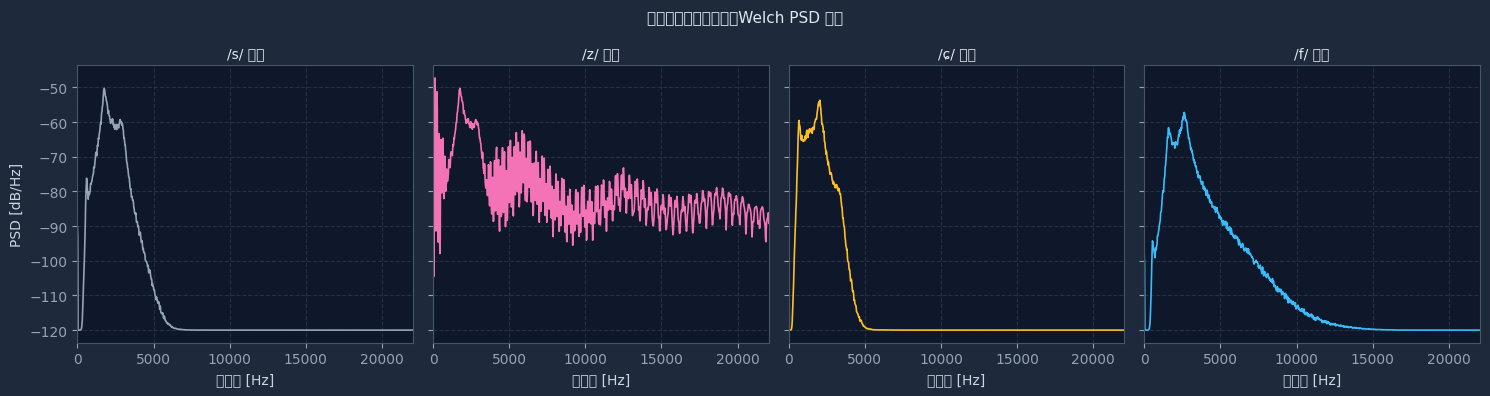

In [7]:
pairs = [
    ('/s/ 無声', synth_fric(FRIC_SHAPES['/s/'])[0],                    '#94a3b8'),
    ('/z/ 有声', wav_z,                                                 '#f472b6'),
    ('/ɕ/ 無声', synth_fric(FRIC_SHAPES['/ɕ/'])[0],                    '#fbbf24'),
    ('/f/ 無声', synth_fric(FRIC_SHAPES['/f/'])[0],                     '#38bdf8'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, (label, wav, col) in zip(axes, pairs):
    fw, P = signal.welch(wav, fs=FS, nperseg=2048)
    ax.plot(fw, 10*np.log10(P+1e-12), color=col, linewidth=1.2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('周波数 [Hz]')
    ax.set_xlim(0, FS/2)
    ax.grid(True)
axes[0].set_ylabel('PSD [dB/Hz]')
fig.suptitle('ハイブリッドモデル：Welch PSD 比較', fontsize=11)
plt.tight_layout()
plt.show()

---
## 6. CV 音節（/sa/ /ɕi/ /ɸu/）の合成

256 サンプルごとに声道形状を補間して更新。  
Re の低下に伴いノイズが自然に消えていく。

In [8]:
def synth_cv(areas_c, areas_v, voiced=True, f0=130., Q_ccps=200.,
             gain=0.55, vr=0.22, dur_c=0.20, dur_t=0.06, dur_v=0.40,
             fs=FS, seed=7):
    """ハイブリッドモデルで CV 音節を合成する。"""
    rng   = np.random.default_rng(seed)
    N_c   = int(dur_c*fs); N_t = int(dur_t*fs); N_v = int(dur_v*fs)
    N_tot = N_c + N_t + N_v
    REF   = 5000.0; FRAME = 256

    glot = make_glottal(N_tot, f0=f0, fs=fs, amp=gain*vr) if voiced \
           else np.zeros(N_tot, dtype=np.float32)

    wg        = WaveguideVocalTract(areas_c, fs=fs, alpha_wall=0.04)
    voice_out = np.zeros(N_tot)
    noise_raw = rng.standard_normal(N_tot).astype(np.float64)
    noise_out = np.zeros(N_tot)

    for fs0 in range(0, N_tot, FRAME):
        fe  = min(fs0 + FRAME, N_tot)
        nm  = (fs0 + fe) // 2
        if   nm < N_c:       cur = areas_c
        elif nm < N_c + N_t: cur = areas_c*(1-(nm-N_c)/N_t) + areas_v*((nm-N_c)/N_t)
        else:                cur = areas_v

        wg.set_areas(cur)
        for n in range(fs0, fe):
            g = float(glot[n]) * 0.5
            for _ in range(OVERSAMPLE): v = wg.step(g)
            voice_out[n] = v

        info = constriction_info(cur, Q_ccps)
        if info['turbulent']:
            chunk = noise_raw[fs0:fe].copy()
            hp, bp, _ = front_cavity_filter(info['L_front_m'], fs)
            chunk = signal.sosfilt(hp, chunk)
            chunk = signal.sosfilt(bp, chunk)
            for _,_,sos in back_cavity_filter(info['L_back_m'], fs):
                chunk = signal.sosfilt(sos, chunk)
            ng = gain*(1-vr)*min(1.0, info['sigma']/REF)
            pk = np.max(np.abs(chunk))
            if pk > 1e-10: chunk = chunk/pk * ng
            noise_out[fs0:fe] = chunk

    pk_v = np.max(np.abs(voice_out))
    if pk_v > 1e-10: voice_out = voice_out/pk_v * gain*vr

    fade = int(0.015*fs)
    env  = np.ones(N_tot)
    env[:fade]  = np.linspace(0,1,fade)
    env[-fade:] = np.linspace(1,0,fade)
    wav = ((noise_out + voice_out)*env).astype(np.float32)
    pk  = np.max(np.abs(wav))
    if pk > 1e-10: wav = wav/pk * gain
    return np.clip(wav, -0.95, 0.95)

print('synth_cv() 定義完了  （各合成に数秒かかります）')

synth_cv() 定義完了  （各合成に数秒かかります）


In [9]:
print('/sa/ 合成中...'); wav_sa  = synth_cv(FRIC_SHAPES['/s/'],  VOWEL_AREAS['a'])
print('/sa/:');  display(Audio(wav_sa,  rate=FS))

/sa/ 合成中...


/sa/:


In [10]:
print('/ɕi/ 合成中...'); wav_shi = synth_cv(FRIC_SHAPES['/ɕ/'],  VOWEL_AREAS['i'])
print('/ɕi/（し）:'); display(Audio(wav_shi, rate=FS))

/ɕi/ 合成中...


/ɕi/（し）:


In [11]:
print('/ɸu/ 合成中...'); wav_fu  = synth_cv(FRIC_SHAPES['/f/'],  VOWEL_AREAS['u'])
print('/ɸu/（ふ）:'); display(Audio(wav_fu,  rate=FS))

/ɸu/ 合成中...


/ɸu/（ふ）:


---
## 7. スペクトログラムと Re 時間変化

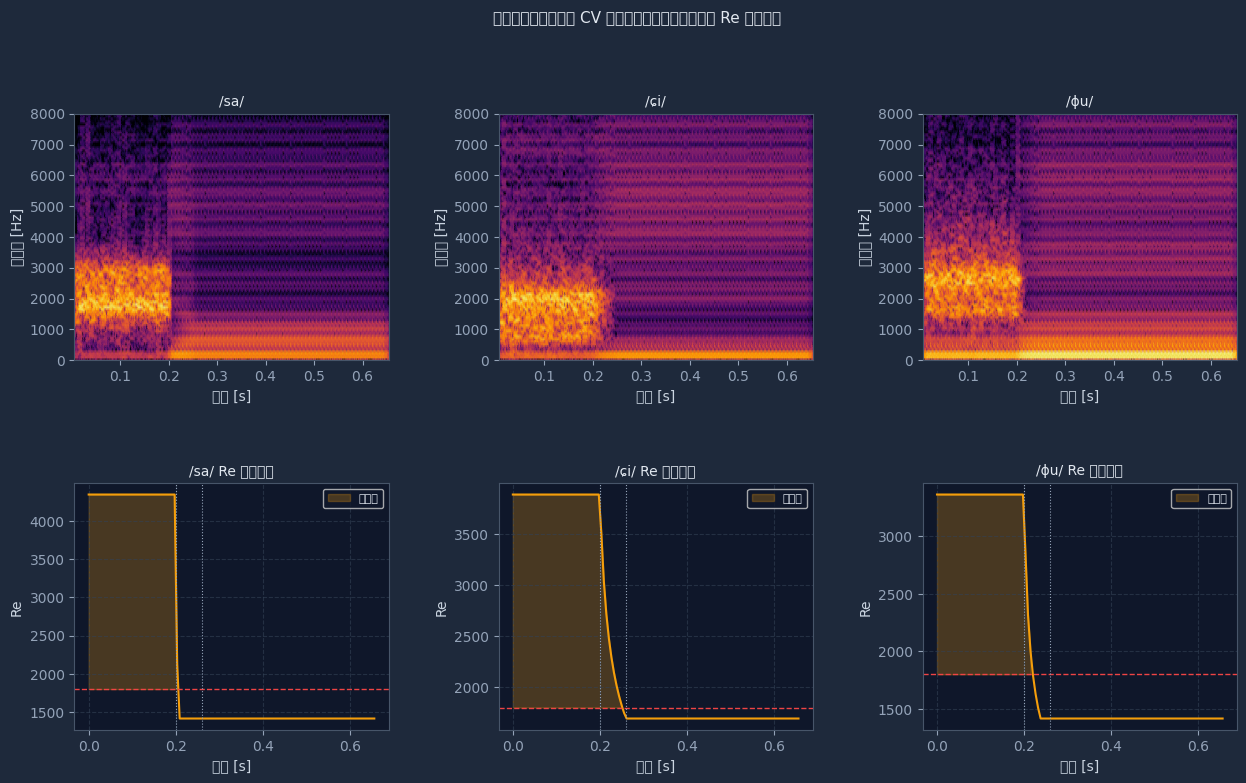

画像を data/processed/analysis/cv_phase3_hybrid.png に保存しました


In [12]:
cv_data = [
    ('/sa/',  wav_sa,  FRIC_SHAPES['/s/'], VOWEL_AREAS['a']),
    ('/ɕi/',  wav_shi, FRIC_SHAPES['/ɕ/'], VOWEL_AREAS['i']),
    ('/ɸu/',  wav_fu,  FRIC_SHAPES['/f/'], VOWEL_AREAS['u']),
]
dur_c, dur_t, dur_v = 0.20, 0.06, 0.40

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.35)

for ci, (label, wav, sc, sv) in enumerate(cv_data):
    N_tot = len(wav)
    N_c   = int(dur_c*FS); N_t = int(dur_t*FS)

    ax_sg = fig.add_subplot(gs[0, ci])
    f_sg, t_sg, Sxx = signal.spectrogram(wav, fs=FS, nperseg=512, noverlap=480)
    Sdb = 10*np.log10(Sxx+1e-12)
    ax_sg.pcolormesh(t_sg, f_sg, Sdb, shading='gouraud', cmap='inferno',
                     vmin=Sdb.max()-50, vmax=Sdb.max())
    ax_sg.set_title(label, fontsize=10)
    ax_sg.set_xlabel('時間 [s]'); ax_sg.set_ylabel('周波数 [Hz]')
    ax_sg.set_ylim(0, 8000)

    ax_re = fig.add_subplot(gs[1, ci])
    step  = 256; times, re_vals = [], []
    for n in range(0, N_tot, step):
        if   n < N_c:       a = sc
        elif n < N_c+N_t:   a = sc*(1-(n-N_c)/N_t) + sv*((n-N_c)/N_t)
        else:               a = sv
        times.append(n/FS)
        re_vals.append(constriction_info(a)['Re'])

    rv = np.array(re_vals)
    ax_re.plot(times, rv, color='#f59e0b', linewidth=1.5)
    ax_re.axhline(RE_CRIT, color='#ef4444', linewidth=1, linestyle='--')
    ax_re.fill_between(times, RE_CRIT, rv, where=rv>RE_CRIT,
                       alpha=0.25, color='#f59e0b', label='乱流域')
    ax_re.axvline(dur_c,       color='#94a3b8', linewidth=0.8, linestyle=':')
    ax_re.axvline(dur_c+dur_t, color='#94a3b8', linewidth=0.8, linestyle=':')
    ax_re.set_xlabel('時間 [s]'); ax_re.set_ylabel('Re')
    ax_re.set_title(f'{label} Re 時間変化', fontsize=10)
    ax_re.legend(fontsize=8); ax_re.grid(True)

fig.suptitle('ハイブリッドモデル CV 音節：スペクトログラムと Re 時間変化', fontsize=11, y=1.01)
plt.savefig('../data/processed/analysis/cv_phase3_hybrid.png',
            dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('画像を data/processed/analysis/cv_phase3_hybrid.png に保存しました')

---
## まとめ

### 問題の根本原因

| 問題 | 原因 | 修正 |
|------|------|------|
| 摩擦音が区別できない | `ALPHA_WALL=0.30` → Q≈2（過減衰）| ハイブリッドモデルへ移行 |
| 全音素が同じノイズ | 7セクション前方腔では共鳴が弱い | Phase 2 の明示フィルタを使用 |

### ハイブリッドモデルの方針

- **摩擦ノイズ**：Phase 2 の前後腔フィルタで高精度な共鳴を再現 → /s/ と /ɕ/ の違いが明確
- **有声成分**：波動管（`alpha_wall=0.04`）が全声道フォルマントを自然に再現
- **CV 遷移**：フレームごとに Re を計算し、収縮が開くにつれて摩擦ノイズが自然に消える

### 次のステップ

1. 実録音（/sa/ /ɕi/）とスペクトログラムを重ねてパラメータを調整する
2. 収縮部形状をより現実的なデータ（MRI 計測値）に更新する
3. このハイブリッドアプローチを第4プロトタイプ（Web）に組み込む